In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.patches import Patch
from shapely.geometry import MultiPolygon, box, Point
from rasterio import features
from affine import Affine
from scipy.ndimage import binary_erosion, binary_dilation
from shapely.geometry import Polygon
from shapely.ops import unary_union

In [2]:
def func_plot(df, variable, filename):
    china = gpd.read_file('../0_map/中国_省_202509_GS(2024)0650.geojson')
    china = china[china['name'] != '境界线'].reset_index(drop=True)
    china_dissolved = china.dissolve()

    cluster_colors = {
        1:'blue',
        2:'orange',
        3:'green', 
        4:'red', 
        5:'purple', 
        6:'brown', 
        7:'pink', 
        8:'gray', 
        9:'olive', 
        10:'cyan', 
        11:'gold', 
        12:'#393B79',
        13:'#637939', 
    }

    df = df.to_crs(epsg=4326)
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_axes([0, 0.5, 0.85, 0.5])
    china_dissolved.boundary.plot(ax=ax, color='black', linewidth=1.0)
    for i in range(1, 14, 1):
        tmp=df[df[variable]==i].reset_index(drop=True)
        tmp.plot(ax=ax, facecolor=cluster_colors[i], edgecolor='none')
        
    ax.set_xlim(72, 136)
    ax.set_ylim(17, 55)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    # plt.savefig(f'../../1_small_mammals/output/9_smoothe/smoothe_{int(threshold)}_{int(cell_size / 1e3)}km_{method}_{n_cluster}_{filename}.tif', bbox_inches='tight', pad_inches=0.05, dpi=300)
    plt.show()

In [3]:
def fill_blank_iterative(merged, variable1, variable2):
    gdf = merged.copy().reset_index(drop=True)
    gdf = gdf.to_crs(epsg=3857)
    gdf['centroid'] = gdf.geometry.centroid

    # 估算栅格边长
    sample_poly = gdf.geometry.iloc[0]
    minx, miny, maxx, maxy = sample_poly.bounds
    grid_size = max(maxx - minx, maxy - miny)

    # 邻近距离（对角线）
    neighbor_dist = grid_size * 1.42 + 1e-6 #1.42
    # # 邻近距离为正方向的上下左右（4邻域）
    # neighbor_dist = grid_size + 1e-6  # 不使用对角线1.42倍
    
    # 初始化 filled_cluster 列
    gdf[variable2] = gdf[variable1]

    max_iter = 1000
    verbose = True
    for i in range(max_iter):
        if verbose:
            print(f"🔁 第 {i+1} 轮填补中...")

        filled_this_round = 0
        gdf_sindex = gdf.sindex

        # 当前空缺列表
        missing_idx = gdf[gdf[variable2].isna()].index

        for idx in missing_idx:
            row = gdf.loc[idx]
            centroid = row['centroid']
            buffer = centroid.buffer(neighbor_dist)
            possible_idx = list(gdf_sindex.intersection(buffer.bounds))
            
            neighbors = gdf.loc[possible_idx]
            neighbors = neighbors[
                (neighbors['centroid'].distance(centroid) <= neighbor_dist) &
                (neighbors[variable2].notna())
            ]

            if len(neighbors) > 0:
                majority = Counter(neighbors[variable2]).most_common(1)[0][0]
                gdf.at[idx, variable2] = majority
                filled_this_round += 1

        if verbose:
            print(f"✅ 第 {i+1} 轮完成：填补 {filled_this_round} 个空缺")

        if filled_this_round == 0:
            if verbose:
                print("🎯 没有更多可填补项，提早结束。")
            break

    return gdf

In [9]:
# # def func_main_part(df, variable1, variable2):
# #     # 1. 保证数据是投影坐标系（用于计算面积/距离）
# #     if df.crs.is_geographic:
# #         df = df.to_crs(epsg=3857)  # 你可以替换为更合适的本地投影
# #     main_parts = []
    
# #     for cluster_id, group in df.dropna(subset=[variable1]).groupby(variable1):
# #         # 对每个 cluster 的 grid 合并为大几何
# #         # dissolved = group.union_all()
# #         dissolved = group.geometry.union_all()

# #         # 如果不是单个聚合体，可能是多个离散块：MultiPolygon
# #         if isinstance(dissolved, MultiPolygon):
# #             parts = list(dissolved.geoms)
# #         else:
# #             parts = [dissolved]

# #         # 找最大部分
# #         largest_part = max(parts, key=lambda geom: geom.area)

# #         # 选出这些 grid 中与最大部分相交的
# #         main = group[group.geometry.intersects(largest_part)]
# #         main_parts.append(main)

# #     # 3. 合并主要部分
# #     main_df = gpd.GeoDataFrame(pd.concat(main_parts), crs=df.crs)

# #     # 4. 添加一个标记列，指示是否属于 cluster 的主要部分
# #     df[variable2] = df.index.isin(main_df.index)
    
# #     return df
# import geopandas as gpd
# from shapely.geometry import MultiPolygon

# def func_main_parts(df, variable1, variable2):
#     """
#     对每个 cluster (variable1) 寻找主要部分：
#     - cluster==6 保留面积最大的前2块
#     - 其他 cluster 保留面积最大的1块
#     并在原始 df 中标记是否属于主要部分 (variable2)。
#     """
#     # 1. 保证数据是投影坐标系（用于计算面积/距离）
#     if df.crs.is_geographic:
#         df = df.to_crs(epsg=3857)  # 可替换为更合适的投影

#     main_parts = []

#     for cluster_id, group in df.dropna(subset=[variable1]).groupby(variable1):
#         # 对每个 cluster 的 grid 合并为大几何
#         dissolved = group.geometry.union_all()

#         # 如果是多个离散块
#         if isinstance(dissolved, MultiPolygon):
#             parts = list(dissolved.geoms)
#         else:
#             parts = [dissolved]

#         # 判断保留数量
#         if cluster_id == 6 or cluster_id==5 or cluster_id==10:
#             num_keep = 2
#         else:
#             num_keep = 1

#         # 按面积排序，选出需要保留的部分
#         parts_sorted = sorted(parts, key=lambda geom: geom.area, reverse=True)
#         top_parts = parts_sorted[:num_keep]

#         # 选出这些 grid 中与前 num_keep 大部分相交的
#         for part in top_parts:
#             main = group[group.geometry.intersects(part)]
#             main_parts.append(main)

#     # 3. 合并主要部分
#     main_df = gpd.GeoDataFrame(pd.concat(main_parts), crs=df.crs)

#     # 4. 添加标记列，指示是否属于 cluster 的主要部分
#     df[variable2] = df.index.isin(main_df.index)

#     return df
import geopandas as gpd
import pandas as pd
from shapely.geometry import MultiPolygon

def func_main_parts(df, variable1, variable2):
    """
    对每个 cluster (variable1) 寻找主要部分：
    - cluster==6,5,10 保留面积最大的前2块
    - 其他 cluster 保留面积最大的1块
    并在原始 df 中标记是否属于主要部分 (variable2)。
    """
    # 1. 保证数据是投影坐标系（用于计算面积/距离）
    if df.crs.is_geographic:
        df = df.to_crs(epsg=3857)  # 可替换为更合适的投影

    main_parts = []

    for cluster_id, group in df.dropna(subset=[variable1]).groupby(variable1):
        # 对每个 cluster 的 grid 合并为大几何
        dissolved = group.geometry.unary_union  # <- 改这里，替代 union_all()

        # 如果是多个离散块
        if isinstance(dissolved, MultiPolygon):
            parts = list(dissolved.geoms)
        else:
            parts = [dissolved]

        # 判断保留数量
        if cluster_id in [5, 6, 10]:
            num_keep = 2
        else:
            num_keep = 1

        # 按面积排序，选出需要保留的部分
        parts_sorted = sorted(parts, key=lambda geom: geom.area, reverse=True)
        top_parts = parts_sorted[:num_keep]

        # 选出这些 grid 中与前 num_keep 大部分相交的
        for part in top_parts:
            main = group[group.geometry.intersects(part)]
            main_parts.append(main)

    # 3. 合并主要部分
    main_df = gpd.GeoDataFrame(pd.concat(main_parts), crs=df.crs)

    # 4. 添加标记列，指示是否属于 cluster 的主要部分
    df[variable2] = df.index.isin(main_df.index)

    return df


In [10]:
def func_itentify(df, resolution, variable1, variable2):
    gdf=df.copy()
    gdf = gdf.to_crs(epsg=3857)  # 使用米单位

    # 栅格参数
    bounds = gdf.total_bounds
    width = int((bounds[2] - bounds[0]) / resolution)
    height = int((bounds[3] - bounds[1]) / resolution)
    transform = Affine.translation(bounds[0], bounds[3]) * Affine.scale(resolution, -resolution)

    # rasterize cluster 栅格（背景为0）
    shapes = [(geom, cluster) for geom, cluster in zip(gdf.geometry, gdf[variable1])]
    raster = features.rasterize(shapes, out_shape=(height, width), transform=transform, fill=0)

    # 初始化标记毛糙区域
    rough_mask_total = np.zeros_like(raster, dtype=bool)

    # 遍历每个 cluster，识别凸起/凹陷
    for cluster_id in np.unique(raster):
        if cluster_id == 0:
            continue  # 跳过背景
        mask = (raster == cluster_id)

        # 膨胀和腐蚀
        eroded = binary_erosion(mask)
        dilated = binary_dilation(mask)

        convex = mask & ~eroded     # 凸起
        concave = dilated & ~mask   # 凹陷

        rough_mask = convex | concave
        rough_mask_total |= rough_mask

    # 获取每个栅格中心点对应的 rough_mask 值
    gdf['centroid'] = gdf.geometry.centroid
    gdf['col'] = ((gdf.centroid.x - bounds[0]) / resolution).astype(int)
    gdf['row'] = ((bounds[3] - gdf.centroid.y) / resolution).astype(int)

    # 越界处理
    gdf['row'] = gdf['row'].clip(0, height - 1)
    gdf['col'] = gdf['col'].clip(0, width - 1)

    # 新增列 is_rough
    gdf[variable2] = gdf.apply(lambda row: rough_mask_total[row['row'], row['col']], axis=1)

    # 如果需要，也可删除临时列
    gdf = gdf.drop(columns=['centroid', 'row', 'col'])   
    return gdf

6098


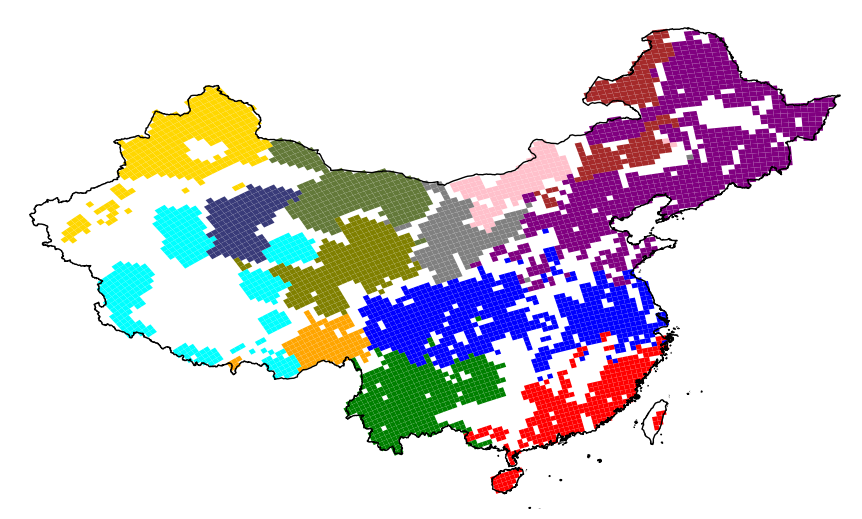

In [11]:
#step1, 轮廓系数为负的栅格，数据缺失的栅格，为填补的对象
scenario='all'
cell_size=40000
threshold=5
silhouette = pd.read_excel(f'output/scenario={scenario}/cell={int(cell_size/1e3)}km/threshold={threshold}/cluster_number/{scenario}_{int(cell_size/1e3)}km_{threshold}_silhouette.xlsx')
map = gpd.read_file(f"output/scenario={scenario}/cell={int(cell_size/1e3)}km/{scenario}_{int(cell_size/1e3)}km_grid_map.geojson")
df = pd.merge(map, silhouette, on='grid_index', how='left')
df['cluster1'] = np.where(df['cluster'].notna() & (df['silhouette_value'] > 0),df['cluster'],np.nan)
df=df[['grid_index', 'geometry', 'cluster', 'cluster1']]
print(df.shape[0])
func_plot(df=df, variable='cluster1', filename='step0')

🔁 第 1 轮填补中...
✅ 第 1 轮完成：填补 1953 个空缺
🔁 第 2 轮填补中...
✅ 第 2 轮完成：填补 19 个空缺
🔁 第 3 轮填补中...
✅ 第 3 轮完成：填补 10 个空缺
🔁 第 4 轮填补中...
✅ 第 4 轮完成：填补 0 个空缺
🎯 没有更多可填补项，提早结束。


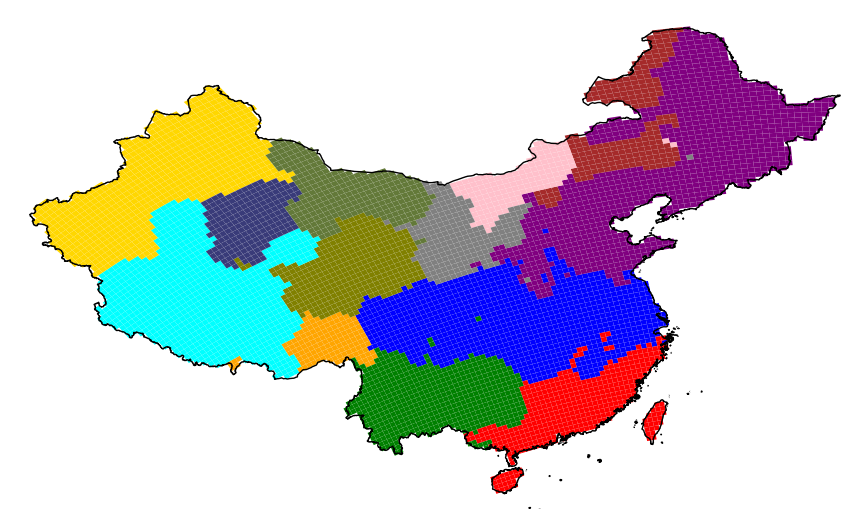

In [12]:
#step2，第一轮填补，基于cluster1，填补到cluster2
df1=fill_blank_iterative(df, 'cluster1', 'cluster2')
func_plot(df=df1, variable='cluster2', filename='step1')

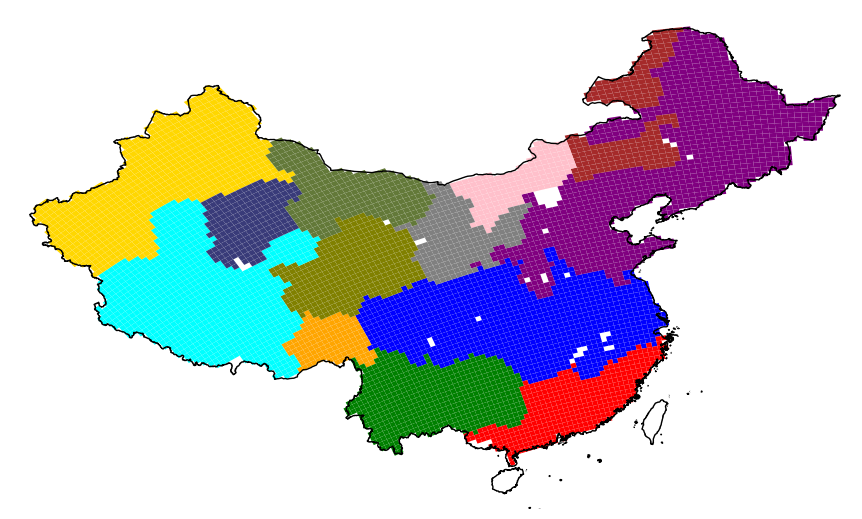

In [13]:
#step3, 识别每个cluster的主要区域，其他栅格作为第二轮填补的对象
df1=func_main_parts(df=df1, variable1='cluster2', variable2='is_main_region_1')
df1['cluster3'] = np.where(df1['is_main_region_1']==True, df1['cluster2'], np.nan)
func_plot(df=df1, variable='cluster3', filename='step2')

🔁 第 1 轮填补中...
✅ 第 1 轮完成：填补 75 个空缺
🔁 第 2 轮填补中...
✅ 第 2 轮完成：填补 4 个空缺
🔁 第 3 轮填补中...
✅ 第 3 轮完成：填补 0 个空缺
🎯 没有更多可填补项，提早结束。


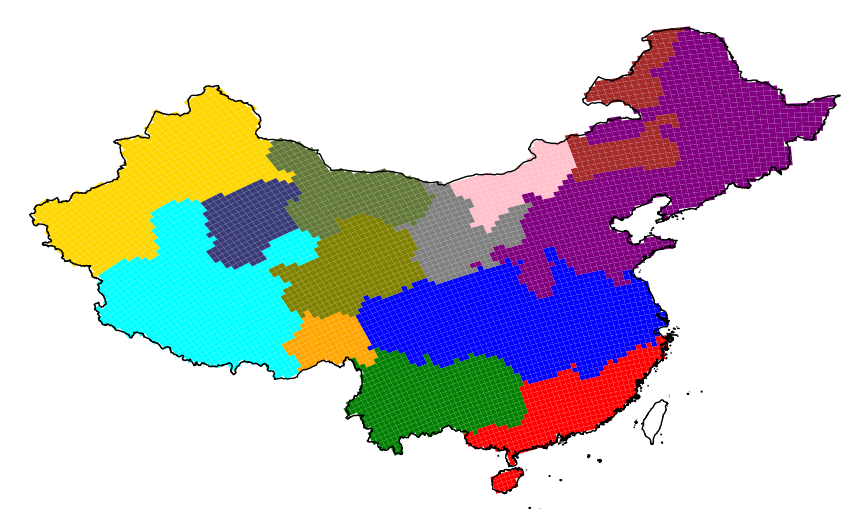

In [14]:
#step4， 第二轮填补，填补其他区域
df2=fill_blank_iterative(df1, 'cluster3', 'cluster4')
func_plot(df=df2, variable='cluster4', filename='step3')

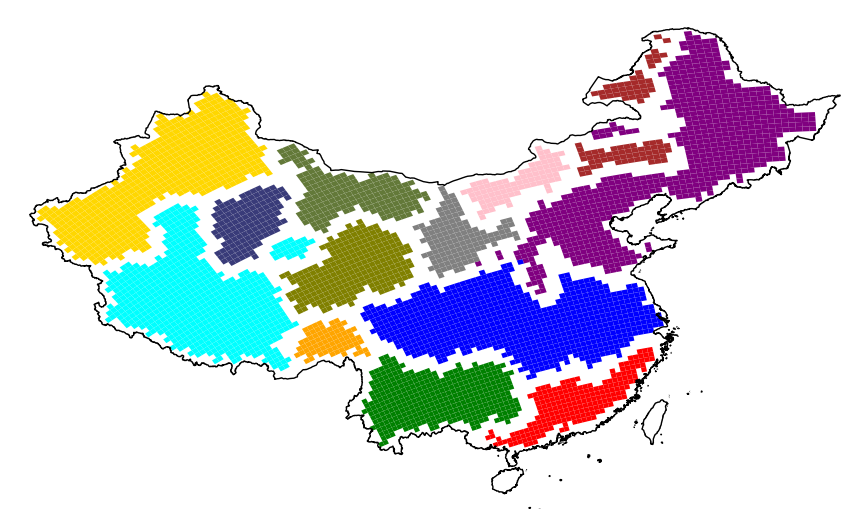

In [15]:
#step5, 识别毛糙栅格
df3=func_itentify(df=df2, resolution=70000, variable1='cluster4', variable2='is_rough_1') #65000
df3['cluster5'] = np.where(df3['is_rough_1']==False, df3['cluster4'], np.nan)
func_plot(df=df3, variable='cluster5', filename='step4')

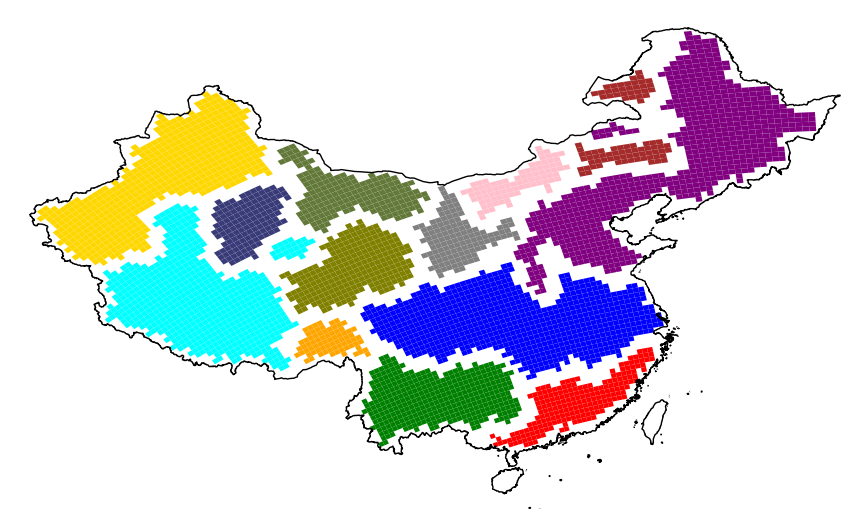

In [16]:
#step6, 识别主要的区域
df3=func_main_parts(df=df3, variable1='cluster5', variable2='is_main_region_2')
df3['cluster6'] = np.where(df3['is_main_region_2']==True, df3['cluster5'], np.nan)
func_plot(df=df3, variable='cluster6', filename='step5')

🔁 第 1 轮填补中...
✅ 第 1 轮完成：填补 1885 个空缺
🔁 第 2 轮填补中...
✅ 第 2 轮完成：填补 24 个空缺
🔁 第 3 轮填补中...
✅ 第 3 轮完成：填补 2 个空缺
🔁 第 4 轮填补中...
✅ 第 4 轮完成：填补 0 个空缺
🎯 没有更多可填补项，提早结束。


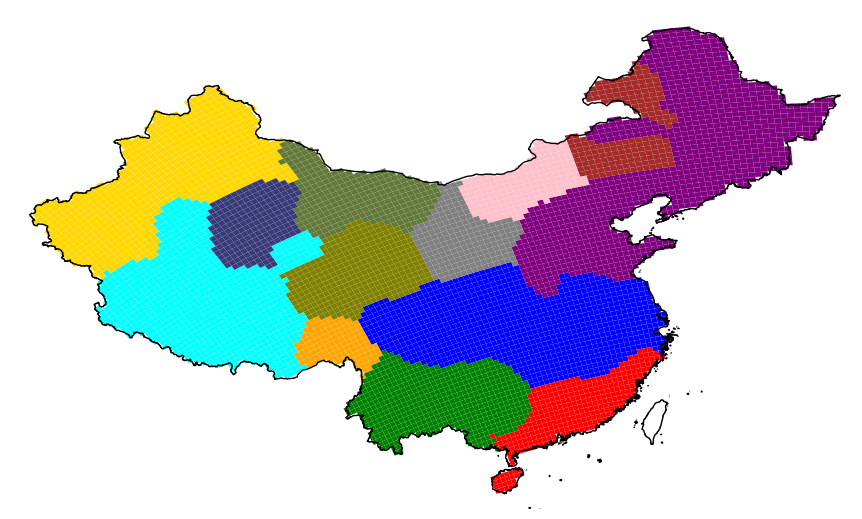

In [17]:
#step7， 进行第三轮填补
df4=fill_blank_iterative(df3, 'cluster6', 'cluster7')
func_plot(df=df4, variable='cluster7', filename='step5')

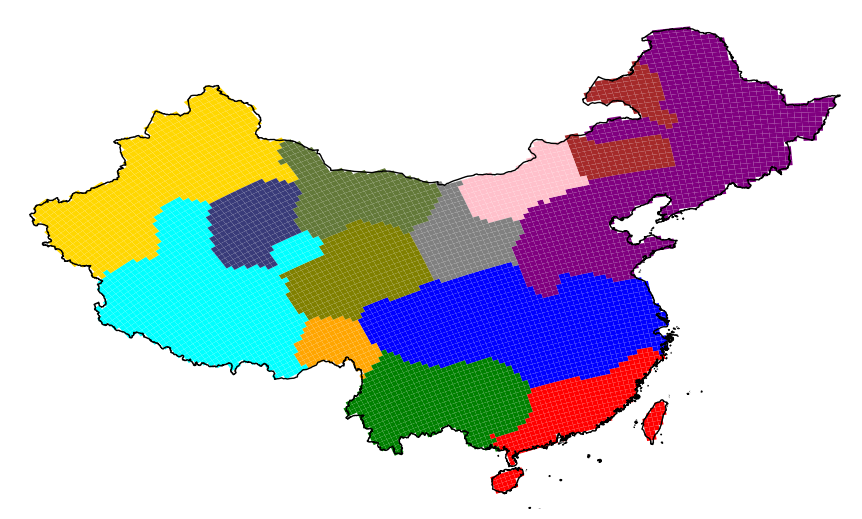

In [18]:
#step8， 处理台湾的栅格
df4['cluster8'] = np.where(df4['cluster7'].notna(), df4['cluster7'], df4['cluster2'])
func_plot(df=df4, variable='cluster8', filename='step7')

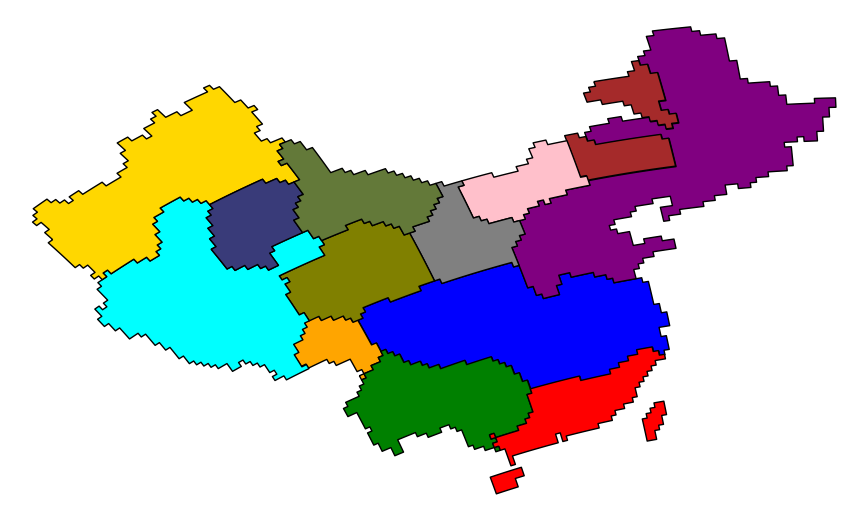

In [20]:
df5=df4.dissolve(by='cluster8').reset_index()
df5=df5[['cluster8', 'geometry']]
df5=df5.rename(columns={"cluster8": 'cluster'})

china = gpd.read_file('../0_map/中国_省_202509_GS(2024)0650.geojson')
china = china[china['name'] != '境界线'].reset_index(drop=True)
china_dissolved = china.dissolve()

cluster_colors = {
        1:'blue',
        2:'orange',
        3:'green', 
        4:'red', 
        5:'purple', 
        6:'brown', 
        7:'pink', 
        8:'gray', 
        9:'olive', 
        10:'cyan', 
        11:'gold', 
        12:'#393B79',
        13:'#637939', 
}

df5 = df5.to_crs(epsg=4326)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_axes([0, 0.5, 0.85, 0.5])
# china_dissolved.boundary.plot(ax=ax, color='black', linewidth=1.0)
for i in range(1, 14, 1):
    tmp=df5[df5['cluster']==i].reset_index(drop=True)
    tmp.plot(ax=ax, facecolor=cluster_colors[i], edgecolor='black')
    
ax.set_xlim(72, 136)
ax.set_ylim(17, 55)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')
for spine in ax.spines.values():
    spine.set_visible(False)
    
# ax_insert = fig.add_axes([0.74, 0.515, 0.1, 0.14])
# for i in range(1, n_cluster + 1):
#     tmp=df5[df5['cluster']==i].reset_index(drop=True)
#     tmp.plot(ax=ax_insert, facecolor=cluster_colors[i], edgecolor='black')
# # china_dissolved.boundary.plot(ax=ax_insert, color='black', linewidth=1)
# ax_insert.set_xlim(105, 125)
# ax_insert.set_ylim(0, 28)
# ax_insert.set_xticks([])
# ax_insert.set_yticks([])
# ax_insert.set_aspect('equal') 

# ax_legend = fig.add_axes([0.01, 0.51, 0.22, 0.12])
# patches = [Patch(facecolor=cluster_colors[i+1], label=f"Region{i+1}",edgecolor='none') for i in range(n_clusters)]
# ax_legend.legend(handles=patches, loc='center',  frameon=False, fontsize=10, ncol=1)
# ax_legend.set_xticks([])
# ax_legend.set_yticks([])
# ax_legend.spines['top'].set_visible(False)
# ax_legend.spines['right'].set_visible(False)
# ax_legend.spines['bottom'].set_visible(False)
# ax_legend.spines['left'].set_visible(False) 
from datetime import datetime
date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
# plt.savefig(f'output/scenario={scenario}/cell={int(cell_size/1e3)}km/threshold={threshold}/cluster_number/{scenario}_{int(cell_size/1e3)}km_{threshold}_zone_boundary_{date_str}.tif', bbox_inches='tight', pad_inches=0.05, dpi=300)
plt.show()

In [ ]:
#分配zone
raw_data=pd.read_excel(f'../../data/host_virus-XL-Zone-20260112.xlsx')
geometry = [Point(xy) for xy in zip(raw_data['lon'], raw_data['lat'])]
raw_gdf = gpd.GeoDataFrame(raw_data, geometry=geometry, crs="EPSG:4326")  # 根据你的坐标设定 CRS
df5 = df5.to_crs(raw_gdf.crs)

joined = gpd.sjoin(raw_gdf, df5[['cluster', 'geometry']], how='left', predicate='within')
# 4. 将匹配结果赋值给 raw_data
raw_data['边界线匹配后的分区'] = joined['cluster'].values
raw_data.to_excel(r'../../data/host_virus-XL-Zone-BoundaryMatch_20260112_new.xlsx', index=False)
raw_data1=raw_data[raw_data['边界线匹配后的分区'].isna()].reset_index(drop=True)

# df5 = df5.to_crs(epsg=4326)
# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_axes([0, 0.5, 0.85, 0.5])
china = gpd.read_file('../0_map/中国_省_202509_GS(2024)0650.geojson')
china = china[china['name'] != '境界线'].reset_index(drop=True)
# china.boundary.plot(ax=ax, color='red', linewidth=1.0)

# china_dissolved.boundary.plot(ax=ax, color='black', linewidth=1.0)
# for i in range(1, 14, 1):
#     tmp=df5[df5['cluster']==i].reset_index(drop=True)
#     tmp.plot(ax=ax, facecolor=cluster_colors[i], edgecolor='black')


# for i in range(raw_data1.shape[0]):
#     ax.scatter(raw_data1['lon'][i], raw_data1['lat'][i], marker='o', s=100, edgecolors='red', facecolor='none')

# # ax.scatter(119.333693, 34.760842, marker='o', s=100, edgecolors='red', facecolor='none')

# ax.set_xlim(72, 136)
# ax.set_ylim(17, 55)
# ax.set_xticks([])
# ax.set_yticks([])
# ax.set_aspect('equal')
# for spine in ax.spines.values():
#     spine.set_visible(False)

# df5 = df5.to_crs(china.crs)
# df5.to_file(f"output/scenario={scenario}/cell={int(cell_size/1e3)}km/threshold={threshold}/cluster_number/{scenario}_{int(cell_size/1e3)}km_{threshold}_zone_boundary_20260115.geojson", driver="GeoJSON")